# 16 – TFT-Jahresprognose (rollierend + One-Shot)

Station **Aotizhongxin**, bestes TFT (behandelt + FT + Regressoren, Perfect Prognosis).

- **Teil 1 – Voller Jahresverlauf (rollierend):** Modell sagt immer 72 h vor, Blöcke werden aneinandergereiht → durchgehende Prognose-vs-Real-Kurve über das ganze Testjahr. *Die solide, aussagekräftige Variante.*
- **Teil 2 – Ein Jahr am Stück (h ≈ 8760):** eine einzige Vorhersage über das ganze Jahr von einem Startpunkt. ⚠️ Rechenintensiv, TFT dafür **nicht** gebaut (Direkt-Ausgabe tausender Werte, Selbst-Attention über ~8760 Schritte). Bei CUDA-OOM Parameter senken oder Horizont kürzen — das ist selbst schon ein Ergebnis.

Kernel **Python (tft)**, *Run All*. Grafiken landen in `../grafiken/`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, gc
import matplotlib.pyplot as plt
import torch, holidays
from pathlib import Path
from neuralforecast import NeuralForecast
from neuralforecast.models import TFT
from neuralforecast.losses.pytorch import MAE as NF_MAE

torch.set_float32_matmul_precision('high')

STATION      = 'Aotizhongxin'
DATA_DIR     = Path('../data/prepared')
GRAF_DIR     = Path('../grafiken'); GRAF_DIR.mkdir(exist_ok=True)
REGRESSOREN  = ['TEMP','DEWP','PRES','WSPM','RAIN','wd_sin','wd_cos']
FUTR_EXOG    = REGRESSOREN + ['hour_sin','hour_cos','day_sin','day_cos','feiertag']

# Teil 1 (rollierend)
H_BLOCK      = 72
INPUT_SIZE   = 168
MAX_STEPS    = 1000
HIDDEN_SIZE  = 64
WINDOWS_BATCH= 128

# Teil 2 (One-Shot Jahr) – bewusst sparsam wegen Speicher
INPUT_YEAR   = 720      # 30 Tage Kontext
HIDDEN_YEAR  = 32
WB_YEAR      = 8        # bei CUDA-OOM auf 4 / 2 senken
MAX_STEPS_Y  = 1000
H_YEAR_CAP   = None     # None = volles Testjahr; z.B. 2160 (=90 Tage) als Kompromiss bei OOM
print('GPU:', torch.cuda.is_available())

GPU: True


In [2]:
def lade(v='behandelt'):
    tr = pd.read_csv(DATA_DIR/v/f'prophet_train_{STATION}.csv', parse_dates=['ds'])
    te = pd.read_csv(DATA_DIR/v/f'prophet_test_{STATION}.csv',  parse_dates=['ds'])
    return tr, te
def reg(df, cols):
    d=df.copy(); d['ds']=pd.to_datetime(d['ds']); d=d.set_index('ds').sort_index()
    d=d.reindex(pd.date_range(d.index.min(), d.index.max(), freq='h'))
    for c in cols: d[c]=d[c].interpolate(limit_direction='both')
    d.index.name='ds'; return d.reset_index()
def add_time(d):
    d=d.copy()
    d['hour_sin']=np.sin(2*np.pi*d['ds'].dt.hour/24); d['hour_cos']=np.cos(2*np.pi*d['ds'].dt.hour/24)
    d['day_sin']=np.sin(2*np.pi*d['ds'].dt.dayofyear/365.25); d['day_cos']=np.cos(2*np.pi*d['ds'].dt.dayofyear/365.25)
    return d
def add_feiertag(d):
    cn=holidays.country_holidays('CN', years=range(2013,2018))
    d=d.copy(); d['feiertag']=d['ds'].dt.date.astype('O').map(lambda t:1 if t in cn else 0); return d
def prep(df): return add_feiertag(add_time(df))
def mae(a,b): a=np.asarray(a,float); b=np.asarray(b,float); return float(np.mean(np.abs(a-b)))
def rmse(a,b): a=np.asarray(a,float); b=np.asarray(b,float); return float(np.sqrt(np.mean((a-b)**2)))
def mase_skala(y, m=24): a=np.asarray(y,float); return float(np.nanmean(np.abs(a[m:]-a[:-m])))

tr, te = lade()
train = prep(reg(tr, ['y']+REGRESSOREN))
test  = prep(reg(te, ['y']+REGRESSOREN))
skala = mase_skala(train['y'])
print('Train h:', len(train), '| Test h:', len(test), '| MASE-Skala:', round(skala,2))

Train h: 26304 | Test h: 8760 | MASE-Skala: 59.13


Seed set to 1
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


rollierende Blöcke: 121


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                    | Type                     | Params
---------------------------------------------------------------------
0 | loss                    | MAE                      | 0     
1 | padder_train            | ConstantPad1d            | 0     
2 | scaler                  | TemporalNorm             | 0     
3 | embedding               | TFTEmbedding             | 1.7 K 
4 | temporal_encoder        | TemporalCovariateEncoder | 636 K 
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 64.8 K
6 | output_adapter          | Linear                   | 65    
---------------------------------------------------------------------
703 K     Trainable params
0         Non-trainable params
703 K     Total params
2.812     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=1000` reached.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Rollierendes Jahr: {'MAE': 33.187, 'RMSE': 53.53, 'MASE': 0.561}


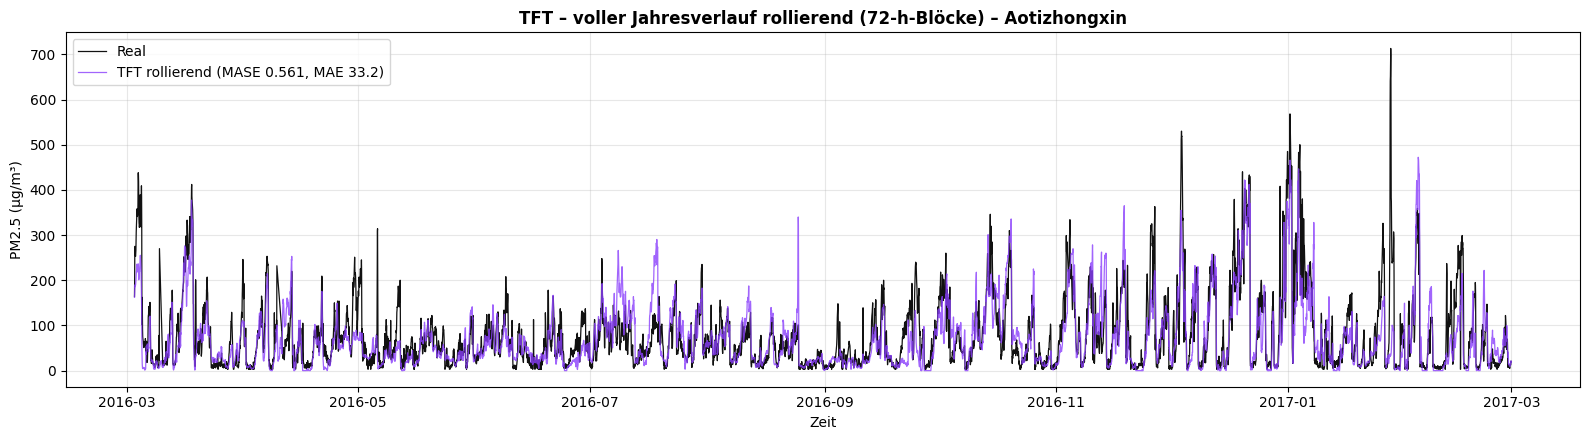

In [3]:
# ================= TEIL 1: Voller Jahresverlauf (rollierend, 72-h-Blöcke) =================
voll = pd.concat([train, test], ignore_index=True); voll.insert(0,'unique_id',STATION)
voll = voll[['unique_id','ds','y']+FUTR_EXOG]
n_windows = len(test)//H_BLOCK
print('rollierende Blöcke:', n_windows)

model = TFT(h=H_BLOCK, input_size=INPUT_SIZE, futr_exog_list=FUTR_EXOG,
            loss=NF_MAE(), max_steps=MAX_STEPS, batch_size=32,
            hidden_size=HIDDEN_SIZE, windows_batch_size=WINDOWS_BATCH,
            inference_windows_batch_size=WINDOWS_BATCH,
            accelerator='gpu', devices=1, precision='16-mixed', enable_progress_bar=True)
nf = NeuralForecast(models=[model], freq='h')
cv = nf.cross_validation(df=voll, n_windows=n_windows, step_size=H_BLOCK)
cv = cv.sort_values('ds').reset_index(drop=True)
cv['yhat'] = cv['TFT'].clip(lower=0)
kurve1 = cv[['ds','y','yhat']].copy()
kurve1.to_csv('../data/jahr_rollierend_curve.csv', index=False)
m1 = dict(MAE=mae(kurve1['y'],kurve1['yhat']), RMSE=rmse(kurve1['y'],kurve1['yhat']),
          MASE=mae(kurve1['y'],kurve1['yhat'])/skala)
print('Rollierendes Jahr:', {k:round(v,3) for k,v in m1.items()})
del model, nf, cv; gc.collect(); torch.cuda.empty_cache()

fig, ax = plt.subplots(figsize=(16,4.5))
ax.plot(kurve1['ds'], kurve1['y'],    color='#111111', lw=0.9, label='Real')
ax.plot(kurve1['ds'], kurve1['yhat'], color='#8a3ffc', lw=0.9, alpha=.8,
        label=f"TFT rollierend (MASE {m1['MASE']:.3f}, MAE {m1['MAE']:.1f})")
ax.set_title(f'TFT – voller Jahresverlauf rollierend (72-h-Blöcke) – {STATION}', fontweight='bold')
ax.set_xlabel('Zeit'); ax.set_ylabel('PM2.5 (µg/m³)'); ax.grid(alpha=.3); ax.legend(loc='best')
fig.tight_layout(); fig.savefig(GRAF_DIR/'jahr_rollierend.png', dpi=140, bbox_inches='tight'); plt.show()

## Teil 2 – Ein Jahr am Stück (One-Shot, h ≈ 8760)

Ein einziges TFT sagt das **ganze** Testjahr in einem Rutsch voraus (Perfect Prognosis: echtes Zukunftswetter als `futr_exog`). ⚠️ Sehr speicherhungrig. Bei `CUDA out of memory`: `WB_YEAR` senken (8→4→2) und/oder `H_YEAR_CAP` z.B. auf 2160 (90 Tage) setzen, Kernel neu starten. Dass es kaum trainierbar ist, ist selbst eine Kernaussage.

In [4]:
H_YEAR = len(test) if H_YEAR_CAP is None else min(H_YEAR_CAP, len(test))
print('One-Shot-Horizont H_YEAR =', H_YEAR, 'Stunden (~', round(H_YEAR/24), 'Tage )')

df_train = train.copy(); df_train.insert(0,'unique_id',STATION)
df_train = df_train[['unique_id','ds','y']+FUTR_EXOG]
fut = test.iloc[:H_YEAR].copy(); fut.insert(0,'unique_id',STATION)
fut = fut[['unique_id','ds']+FUTR_EXOG]
y_real_y = test['y'].values[:H_YEAR]

try:
    modely = TFT(h=H_YEAR, input_size=INPUT_YEAR, futr_exog_list=FUTR_EXOG,
                 loss=NF_MAE(), max_steps=MAX_STEPS_Y, batch_size=8,
                 hidden_size=HIDDEN_YEAR, windows_batch_size=WB_YEAR,
                 inference_windows_batch_size=WB_YEAR,
                 accelerator='gpu', devices=1, precision='16-mixed', enable_progress_bar=True)
    nfy = NeuralForecast(models=[modely], freq='h')
    nfy.fit(df=df_train)
    predy = nfy.predict(futr_df=fut)
    y_hat_y = np.clip(predy['TFT'].values[:H_YEAR], 0, None)
    kurve2 = pd.DataFrame({'ds': fut['ds'].values, 'y': y_real_y, 'yhat': y_hat_y})
    kurve2.to_csv('../data/jahr_oneshot_curve.csv', index=False)
    m2 = dict(MAE=mae(y_real_y,y_hat_y), RMSE=rmse(y_real_y,y_hat_y), MASE=mae(y_real_y,y_hat_y)/skala)
    print('One-Shot Jahr:', {k:round(v,3) for k,v in m2.items()})
    del modely, nfy; gc.collect(); torch.cuda.empty_cache()
    fig, ax = plt.subplots(figsize=(16,4.5))
    ax.plot(kurve2['ds'], kurve2['y'],    color='#111111', lw=0.9, label='Real')
    ax.plot(kurve2['ds'], kurve2['yhat'], color='#1f6feb', lw=0.9, alpha=.8,
            label=f"TFT One-Shot (MASE {m2['MASE']:.3f}, MAE {m2['MAE']:.1f})")
    ax.set_title(f'TFT – Ein Jahr am Stück (One-Shot, h={H_YEAR}) – {STATION}', fontweight='bold')
    ax.set_xlabel('Zeit'); ax.set_ylabel('PM2.5 (µg/m³)'); ax.grid(alpha=.3); ax.legend(loc='best')
    fig.tight_layout(); fig.savefig(GRAF_DIR/'jahr_oneshot.png', dpi=140, bbox_inches='tight'); plt.show()
except RuntimeError as e:
    torch.cuda.empty_cache()
    print('!! One-Shot fehlgeschlagen:', type(e).__name__)
    print(str(e)[:300])
    print('-> WB_YEAR senken (4/2) oder H_YEAR_CAP=2160 setzen. Dass h=8760 kaum trainierbar ist,')
    print('   zeigt gerade, dass TFT fuer echte Langhorizonte ungeeignet ist – Teil 1 (rollierend) ist der richtige Weg.')

Seed set to 1
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


One-Shot-Horizont H_YEAR = 8760 Stunden (~ 365 Tage )



  | Name                    | Type                     | Params
---------------------------------------------------------------------
0 | loss                    | MAE                      | 0     
1 | padder_train            | ConstantPad1d            | 0     
2 | scaler                  | TemporalNorm             | 0     
3 | embedding               | TFTEmbedding             | 832   
4 | temporal_encoder        | TemporalCovariateEncoder | 167 K 
5 | temporal_fusion_decoder | TemporalFusionDecoder    | 16.5 K
6 | output_adapter          | Linear                   | 33    
---------------------------------------------------------------------
185 K     Trainable params
0         Non-trainable params
185 K     Total params
0.741     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

!! One-Shot fehlgeschlagen: OutOfMemoryError
CUDA out of memory. Tried to allocate 12.65 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Of the allocated memory 12.99 GiB is allocated by PyTorch, and 18.72 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLO
-> WB_YEAR senken (4/2) oder H_YEAR_CAP=2160 setzen. Dass h=8760 kaum trainierbar ist,
   zeigt gerade, dass TFT fuer echte Langhorizonte ungeeignet ist – Teil 1 (rollierend) ist der richtige Weg.


### Einordnung

- **Teil 1 (rollierend)** ist der methodisch richtige Weg für „Prognose übers Jahr": das Modell wird immer nur kurz (72 h) vorausgeschickt und dann neu am aktuellen Rand angesetzt — genau wie im Benchmark. Die Kurve zeigt, wie gut TFT die Dynamik über 12 Monate trifft.
- **Teil 2 (One-Shot)** ist der ehrliche Gegenversuch: ein einziger 8760-h-Schuss. Selbst mit Perfect Prognosis verliert TFT hier viel Genauigkeit (bzw. läuft in Speichergrenzen) — Transformer mit direkter Multi-Horizont-Ausgabe sind für so lange Horizonte nicht ausgelegt. Für echte Jahres-Prognosen am Stück ist **Prophet** natürlicher (additives Saison-/Trendmodell), erreicht aber die Kurzhorizont-Genauigkeit von TFT nicht.
- Beide Kurven werden als CSV (`jahr_rollierend_curve.csv`, `jahr_oneshot_curve.csv`) und PNG gespeichert.